# Week 1 — Data Exploration
**Project:** AI-Assisted Drug Target Discovery — *Klebsiella pneumoniae*  
**Author:** Bacha Zada, M.Sc. Computational Biology, University of Göttingen

This notebook explores the downloaded proteome and essential gene data before filtering.

In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from Bio import SeqIO
from collections import Counter

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load config
with open('../config.yaml') as f:
    config = yaml.safe_load(f)

print('Config loaded. Organism:', config['organism']['name'])

Config loaded. Organism: Klebsiella pneumoniae


## 1. Load the proteome

In [2]:
# Load all sequences
proteome_path = f"../{config['paths']['raw_proteome']}"
records = list(SeqIO.parse(proteome_path, 'fasta'))

print(f'Total proteins: {len(records)}')
print(f'\nFirst record:')
print(f'  ID:     {records[0].id}')
print(f'  Length: {len(records[0].seq)} aa')
print(f'  Desc:   {records[0].description[:80]}...')

Total proteins: 5126

First record:
  ID:     tr|A6T5J6|A6T5J6_KLEP7
  Length: 287 aa
  Desc:   tr|A6T5J6|A6T5J6_KLEP7 Acyl-CoA thioesterase 2 OS=Klebsiella pneumoniae subsp. p...


## 2. Build a summary dataframe

In [3]:
# Parse each FASTA record into a structured dataframe
rows = []
for rec in records:
    desc = rec.description
    # Extract gene name if present (format: GN=xxxxx)
    gene = ''
    if 'GN=' in desc:
        gene = desc.split('GN=')[1].split(' ')[0]
    # Extract UniProt entry type (sp = reviewed, tr = unreviewed)
    entry_type = 'reviewed (sp)' if rec.id.startswith('sp|') else 'unreviewed (tr)'
    rows.append({
        'uniprot_id': rec.id,
        'gene_name': gene,
        'length': len(rec.seq),
        'entry_type': entry_type,
        'description': rec.description[:100]
    })

df = pd.DataFrame(rows)
print(df.head(5).to_string())
print(f'\nEntry types:\n{df.entry_type.value_counts()}')

               uniprot_id gene_name  length       entry_type                                                                                           description
0  tr|A6T5J6|A6T5J6_KLEP7      tesB     287  unreviewed (tr)  tr|A6T5J6|A6T5J6_KLEP7 Acyl-CoA thioesterase 2 OS=Klebsiella pneumoniae subsp. pneumoniae (strain AT
1  tr|A6T5Q2|A6T5Q2_KLEP7      tesA     197  unreviewed (tr)  tr|A6T5Q2|A6T5Q2_KLEP7 Thioesterase 1/protease 1/lysophospholipase L1 OS=Klebsiella pneumoniae subsp
2    sp|A6T7D6|PYRC_KLEP7      pyrC     348    reviewed (sp)  sp|A6T7D6|PYRC_KLEP7 Dihydroorotase OS=Klebsiella pneumoniae subsp. pneumoniae (strain ATCC 700721 /
3    sp|A6T923|HPXO_KLEP7      hpxO     384    reviewed (sp)  sp|A6T923|HPXO_KLEP7 FAD-dependent urate hydroxylase OS=Klebsiella pneumoniae subsp. pneumoniae (str
4    sp|A6TB83|MTFA_KLEP7      mtfA     265    reviewed (sp)  sp|A6TB83|MTFA_KLEP7 Mlc titration factor A OS=Klebsiella pneumoniae subsp. pneumoniae (strain ATCC 

Entry types:
entry_ty

## 3. Protein length distribution

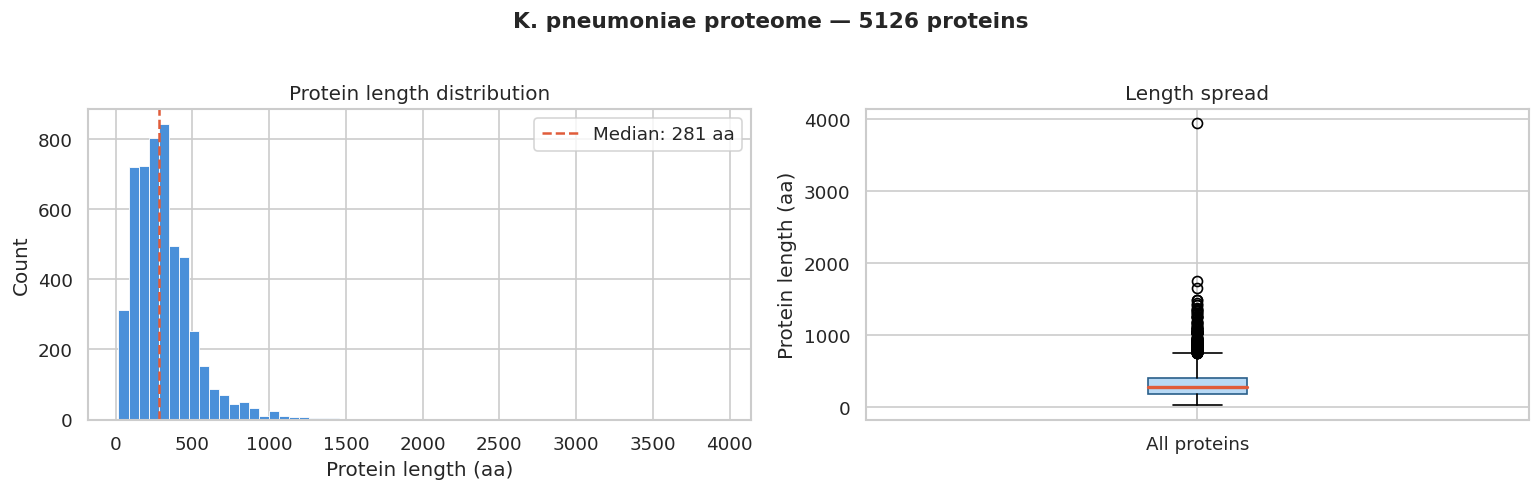

Plot saved to visualizations/


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of lengths
axes[0].hist(df['length'], bins=60, color='#4A90D9', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['length'].median(), color='#E05C3A', linewidth=1.5,
                linestyle='--', label=f"Median: {df['length'].median():.0f} aa")
axes[0].set_xlabel('Protein length (aa)')
axes[0].set_ylabel('Count')
axes[0].set_title('Protein length distribution')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['length'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#B8D9F5', color='#2A5F8A'),
                medianprops=dict(color='#E05C3A', linewidth=2))
axes[1].set_ylabel('Protein length (aa)')
axes[1].set_title('Length spread')
axes[1].set_xticklabels(['All proteins'])

plt.suptitle(f'K. pneumoniae proteome — {len(df)} proteins', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/proteome_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to visualizations/')

## 4. Amino acid composition (global)

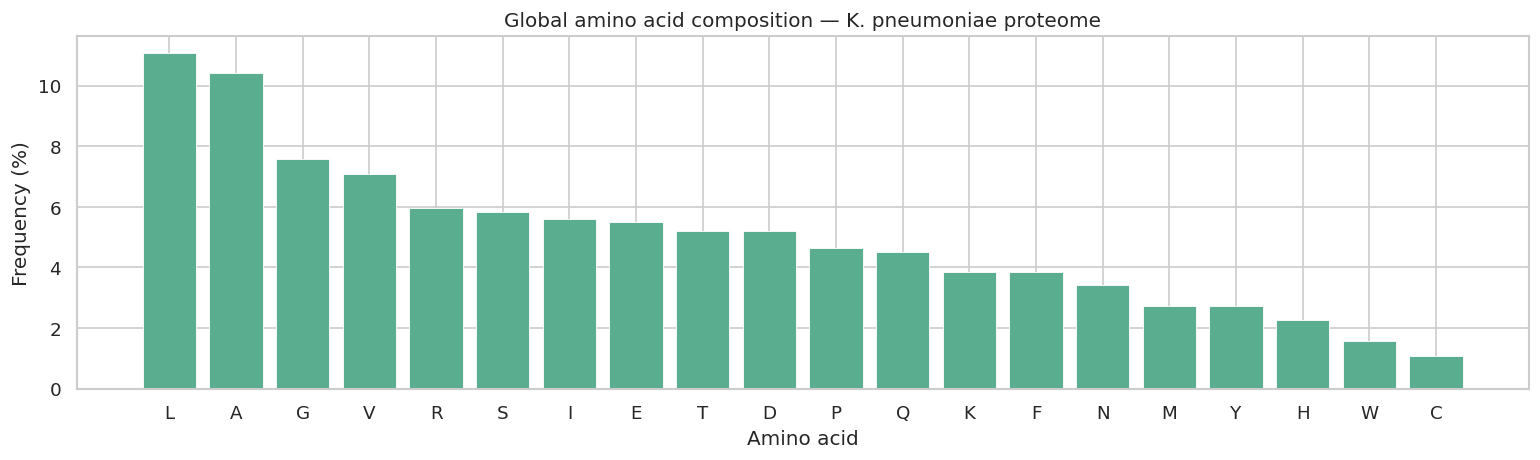

In [8]:
# Count all amino acids across the entire proteome
all_seqs = ''.join(str(r.seq) for r in records)
aa_counts = Counter(c for c in all_seqs if c.isalpha())

aa_df = pd.DataFrame({'aa': list(aa_counts.keys()),
                       'count': list(aa_counts.values())})
aa_df['frequency'] = aa_df['count'] / aa_df['count'].sum() * 100
aa_df = aa_df.sort_values('frequency', ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(aa_df['aa'], aa_df['frequency'], color='#5BAD8F', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Amino acid')
ax.set_ylabel('Frequency (%)')
ax.set_title('Global amino acid composition — K. pneumoniae proteome')

plt.tight_layout()
plt.savefig('../visualizations/aa_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Essential genes — overlap check

In [9]:
# Load essential genes
eg_path = f"../{config['paths']['essential_genes']}"
with open(eg_path) as f:
    essential = set(l.strip() for l in f if l.strip() and not l.startswith('#'))

print(f'Essential genes loaded: {len(essential)}')

# How many proteome entries match an essential gene by name?
df['is_essential'] = df['gene_name'].isin(essential)
n_essential_found = df['is_essential'].sum()

print(f'Proteins with essential gene name match: {n_essential_found} / {len(df)}')
print(f'({n_essential_found/len(df)*100:.1f}% of proteome)')

# Show some matched examples
print('\nMatched examples:')
print(df[df['is_essential']][['gene_name','length','description']].head(8).to_string())

Essential genes loaded: 154
Proteins with essential gene name match: 155 / 5126
(3.0% of proteome)

Matched examples:
   gene_name  length                                                                                           description
11      murE     495  tr|A6T4M8|A6T4M8_KLEP7 UDP-N-acetylmuramoyl-L-alanyl-D-glutamate--2,6-diaminopimelate ligase OS=Kleb
46      dnaJ     377  sp|A6T4F5|DNAJ_KLEP7 Chaperone protein DnaJ OS=Klebsiella pneumoniae subsp. pneumoniae (strain ATCC 
48      ileS     922  tr|A6T4G0|A6T4G0_KLEP7 Isoleucine--tRNA ligase OS=Klebsiella pneumoniae subsp. pneumoniae (strain AT
68      ftsI     588  tr|A6T4M7|A6T4M7_KLEP7 Peptidoglycan D,D-transpeptidase FtsI OS=Klebsiella pneumoniae subsp. pneumon
69      murF     452  tr|A6T4M9|A6T4M9_KLEP7 UDP-N-acetylmuramoyl-tripeptide--D-alanyl-D-alanine ligase OS=Klebsiella pneu
70      mraY     360  sp|A6T4N0|MRAY_KLEP7 Phospho-N-acetylmuramoyl-pentapeptide-transferase OS=Klebsiella pneumoniae subs
71      murD     438 

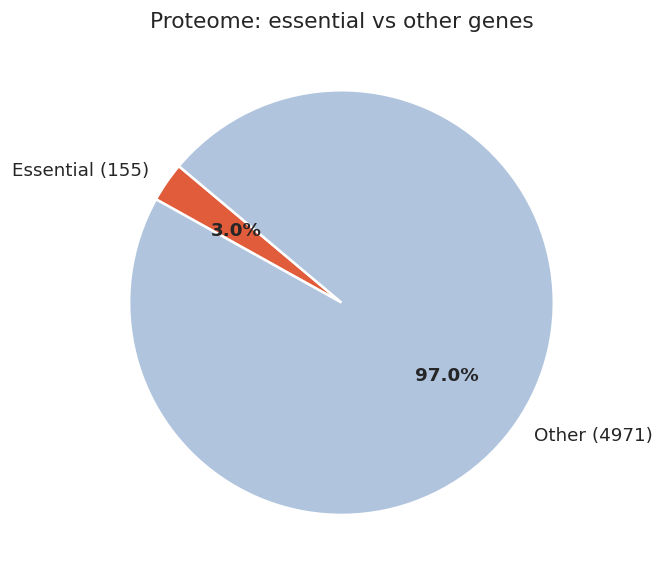

In [10]:
# Pie chart: essential vs non-essential in proteome
fig, ax = plt.subplots(figsize=(6, 5))
sizes  = [n_essential_found, len(df) - n_essential_found]
labels = [f'Essential ({n_essential_found})', f'Other ({len(df)-n_essential_found})']
colors = ['#E05C3A', '#B0C4DE']

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')

ax.set_title('Proteome: essential vs other genes', fontsize=13)
plt.tight_layout()
plt.savefig('../visualizations/essential_genes_pie.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save summary table

In [11]:
# Save the summary dataframe — useful for later steps
out_path = '../data/proteome_summary.csv'
df.to_csv(out_path, index=False)
print(f'Summary table saved: {out_path}')
print(f'\nColumns: {list(df.columns)}')
print(f'Shape: {df.shape}')

print('\n--- Week 1 complete ---')
print('Next step: run scripts/02_filter_targets.py')

Summary table saved: ../data/proteome_summary.csv

Columns: ['uniprot_id', 'gene_name', 'length', 'entry_type', 'description', 'is_essential']
Shape: (5126, 6)

--- Week 1 complete ---
Next step: run scripts/02_filter_targets.py
